In [46]:
######################
# 0. 코랩 환경 준비
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics opencv-python

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
######################
# 1. YOLOv8 포츠 추정 모델 불러오기
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/models/yolov8m-pose.pt")

In [48]:
######################
# 2. 모델 추론
import torch

def predict(frame, iou=0.7, conf=0.25):
    results = model(
        source=frame,
        device="0" if torch.cuda.is_available() else "cpu",
        iou=0.7,
        conf=0.25,
        verbose=False,
    )
    result = results[0]
    return result

In [49]:
######################
# 3. 경계 상자 시각화
def draw_boxes(result, frame):
    for boxes in result.boxes:
        x1, y1, x2, y2, score, classes = boxes.data.squeeze().cpu().numpy()
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 1)
    return frame

In [50]:
######################
# 4. 키 포인트 시각화 (Colab + 최신 Ultralytics)
from ultralytics.utils.plotting import Annotator
from google.colab.patches import cv2_imshow
import cv2

def draw_keypoints(result, frame, show=False):
    annotator = Annotator(frame, line_width=2)

    # keypoints 없을 때 대비
    if result.keypoints is None or len(result.keypoints) == 0:
        if show:
            cv2_imshow(frame)
        return frame

    # 전체 keypoints tensor (N, K, 3)
    kps_all = result.keypoints.data

    for person_kps in kps_all:
        # skeleton 포함 기본 그리기
        annotator.kpts(person_kps)

        nkps = person_kps.cpu().numpy()

        for idx, (x, y, score) in enumerate(nkps):
            if score > 0.3:   # threshold 낮추는 게 중요
                cv2.circle(frame, (int(x), int(y)), 4, (0, 0, 255), -1)
                cv2.putText(
                    frame,
                    str(idx),
                    (int(x), int(y)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    1
                )

    # Colab 출력 옵션
    if show:
        cv2_imshow(frame)

    return frame


0: 384x640 8 persons, 1274.1ms
Speed: 5.0ms preprocess, 1274.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


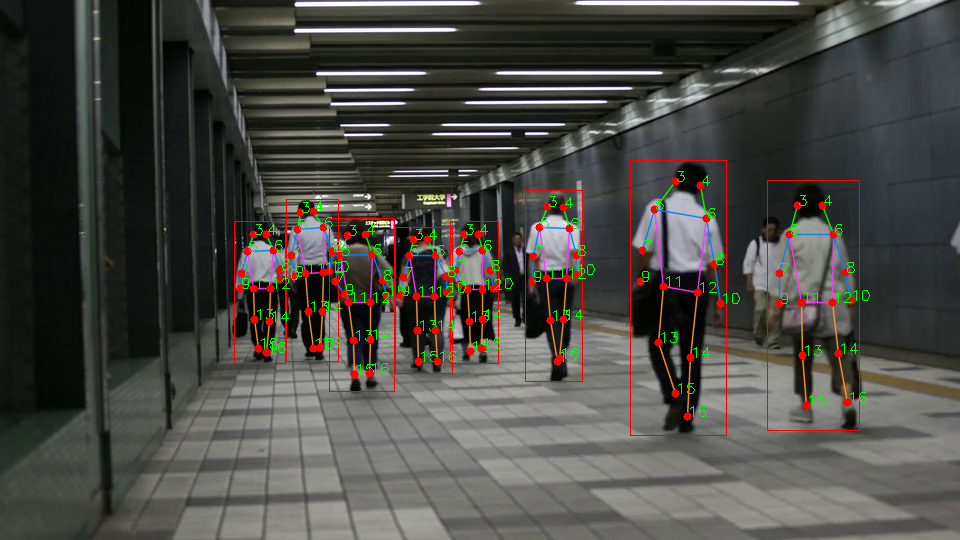


0: 384x640 9 persons, 1184.0ms
Speed: 6.4ms preprocess, 1184.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 819.4ms
Speed: 4.3ms preprocess, 819.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 829.3ms
Speed: 3.5ms preprocess, 829.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 819.4ms
Speed: 3.5ms preprocess, 819.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 818.8ms
Speed: 3.8ms preprocess, 818.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 807.3ms
Speed: 3.1ms preprocess, 807.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 813.4ms
Speed: 5.6ms preprocess, 813.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 833.5ms
Speed: 3.7ms preprocess, 833.5ms inference, 1.0ms postprocess p

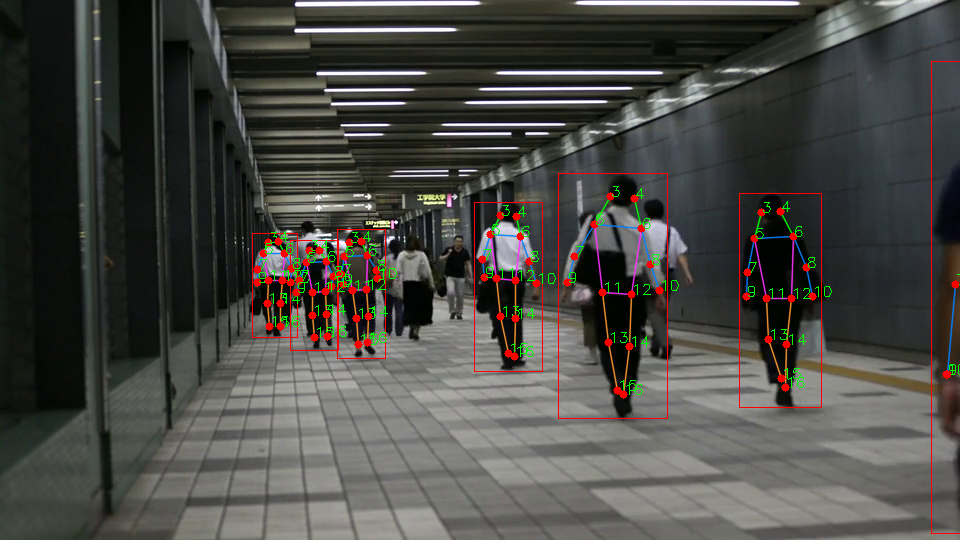


0: 384x640 7 persons, 1305.8ms
Speed: 4.4ms preprocess, 1305.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 1292.3ms
Speed: 4.6ms preprocess, 1292.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 817.7ms
Speed: 5.3ms preprocess, 817.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 825.9ms
Speed: 5.4ms preprocess, 825.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 820.2ms
Speed: 3.3ms preprocess, 820.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 824.8ms
Speed: 3.2ms preprocess, 824.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 823.9ms
Speed: 3.5ms preprocess, 823.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 805.2ms
Speed: 4.6ms preprocess, 805.2ms inference, 1.2ms postprocess 

KeyboardInterrupt: 

In [53]:
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# 반드시 pose 모델 사용
#model = YOLO("yolov8n-pose.pt")

#capture = cv2.VideoCapture("/content/drive/MyDrive/datasets/woman.mp4")
capture = cv2.VideoCapture("/content/drive/MyDrive/datasets/airport.mp4")

frame_count = 0

while True:
    ret, frame = capture.read()

    if not ret:
        break

    # 모델 추론 (results는 리스트)
    results = model(frame)

    for result in results:
        # 박스 + 키포인트 둘 다 적용
        frame = draw_boxes(result, frame)
        frame = draw_keypoints(result, frame)

    # Colab 출력 최적화
    if frame_count % 60 == 0:
        cv2_imshow(frame)

    frame_count += 1

capture.release()